# More than a point estimate

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/multimodal.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/multimodal.ipynb)

A single number per row hides most of what a model of $p(y \mid x)$ knows. In
this tutorial, we predict the annual medical insurance charges of
individuals, a target which splits into bands, so that for some people the
predicted distribution has two peaks and its mean falls between them, where
there is little probability. We compare the four point estimates of `lazy`,
draw samples from the distributions, and score them with proper scoring rules
alongside the usual point metrics.

## Setup

On Google Colab, the cell below installs the package with the TabPFN backend.
Elsewhere, install it first with `pip install 'lazy-tfm[tabpfn]'`.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn]'
    pass

In [2]:
import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables
from scipy import signal  # Peak finding
from sklearn import model_selection  # Train/test split

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

The `insurance` dataset holds the annual medical charges billed to 1,338
individuals in the United States, with their age, sex, body mass index
(BMI), number of children, smoking status and region. Three of the six
columns are categorical.

In [3]:
data = datasets.load_dataset("insurance")
X, y = data.X.copy(), data.y
X.head()

,age,sex,bmi,children,smoker,region
0,45,female,25.175,2,no,northeast
1,36,female,30.020,0,no,northwest
2,64,female,26.885,0,yes,northwest
3,46,male,25.745,3,no,northwest
4,19,male,31.920,0,yes,northwest


Since the models accept only numbers, we first replace each categorical
column by its integer codes (the
[messy_inputs](https://lazy-tfm.readthedocs.io/en/latest/tutorials/messy_inputs.html)
tutorial covers this and other preparation in more detail). We then hold out
a quarter of the rows as the test set, which leaves 1,003 rows as the
context.

In [4]:
categorical = ["sex", "smoker", "region"]
for column in categorical:
    print(column, dict(enumerate(X[column].cat.categories)))
    X[column] = X[column].cat.codes

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.25, random_state=SEED
)
print(f"{len(X_train):,} context rows, {len(X_test):,} test rows")

sex {0: 'female', 1: 'male'}
smoker {0: 'no', 1: 'yes'}
region {0: 'northeast', 1: 'northwest', 2: 'southeast', 3: 'southwest'}
1,003 context rows, 335 test rows


The figure below shows the charges of the context rows against age, split
into three groups by smoking status and by whether the BMI exceeds 30 (the
conventional threshold for obesity).

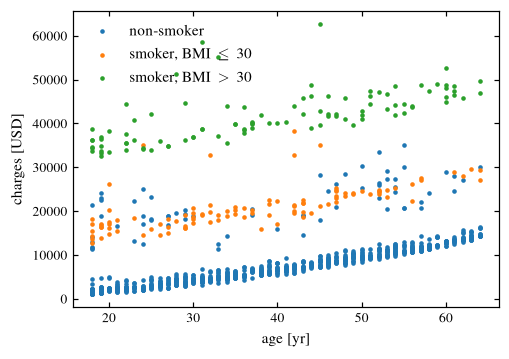

In [5]:
smoker = X_train["smoker"] == 1
obese = X_train["bmi"] > 30
groups = {
    "non-smoker": ~smoker,
    "smoker, BMI $\\leq$ 30": smoker & ~obese,
    "smoker, BMI $>$ 30": smoker & obese,
}
fig, ax = plt.subplots(figsize=(5, 3.5))
for label, rows in groups.items():
    ax.scatter(X_train["age"][rows], y_train[rows], s=4, label=label)
ax.set_xlabel("age [yr]")
ax.set_ylabel("charges [USD]")
ax.legend()

We see that the charges lie in three nearly separate bands, each rising
with age. Non-smokers form the lowest band (with a sparse scatter above it),
smokers with a BMI up to 30 sit about \$15,000 higher, and smokers with a
BMI above 30 about \$20,000 higher still. Therefore, for a smoker whose BMI
is close to 30, a small change in a single feature moves the charges by
more than \$15,000, and the distribution of the charges given the features
may well have a peak in each band.

## Densities

We fit the default model (TabPFN-3.5) and evaluate the densities of the test
set on a grid of 650 bins of \$100 each between \$0 and \$65,000, which are
narrow compared with the gaps between the bands and wide enough to keep the
densities free of jitter from one bin to the next.

In [6]:
model = lazy.LazyModel(random_state=SEED)
model.fit(X_train, y_train)

grid = lazy.Grid.from_edges(np.linspace(0, 65_000, 651))
pdfs = model.predict_proba(X_test, grid)
pdfs.shape

(335, 650)

To check how often the densities have more than one peak, we count, for
each test row, the local maxima that reach at least 10% of the highest
density of that row and stand out from their surroundings by as much.

In [7]:
n_peaks = np.array(
    [
        len(
            signal.find_peaks(
                p, height=0.1 * p.max(), prominence=0.1 * p.max()
            )[0]
        )
        for p in pdfs
    ]
)
print(pd.Series(n_peaks).value_counts().sort_index().to_string())
multimodal = np.flatnonzero(n_peaks > 1)
X_test.iloc[multimodal].assign(charges=y_test[multimodal])

1    332
2      3


,age,sex,bmi,children,smoker,region,charges
137,42,1,30.00,0,1,3,22144.0320
676,25,1,29.70,3,1,3,19933.4580
652,24,1,29.83,0,1,0,18648.4217


Only 3 of the 335 test densities have a second peak by this criterion, all of
them for smokers whose BMI lies between 29.70 and 30.00, just at or below the
threshold. Every other density has a single peak above 10% of its maximum.
The figure below shows the densities of these three people with their mean,
median, mode and true charges.

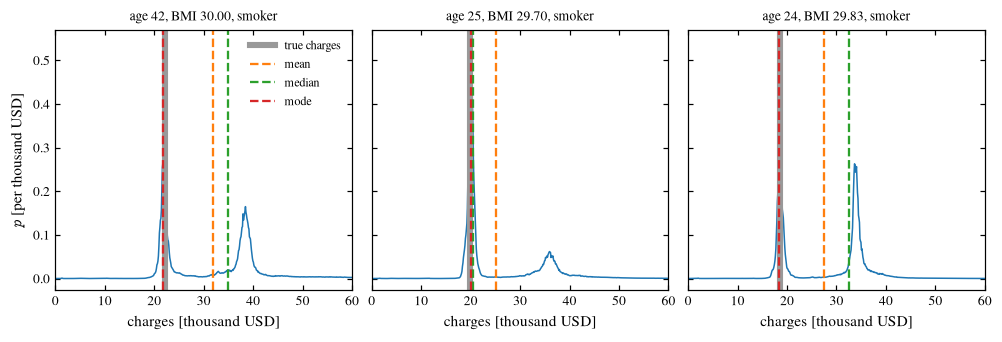

In [8]:
estimates = metrics.grid_point_estimates(grid, pdfs)
marks = {"mean": "C1", "median": "C2", "mode": "C3"}

shown = multimodal[:4]
fig, axes = plt.subplots(
    1,
    len(shown),
    figsize=(3 * len(shown), 3),
    sharey=True,
    layout="constrained",
    squeeze=False,
)
axes = axes[0]
for ax, i in zip(axes, shown):
    ax.plot(grid.centers / 1e3, pdfs[i] * 1e3, color="C0", lw=1)
    ax.axvline(y_test[i] / 1e3, color="0.6", lw=4, label="true charges")
    for name, color in marks.items():
        ax.axvline(estimates[name][i] / 1e3, color=color, ls="--", label=name)
    row = X_test.iloc[i]
    ax.set_title(
        f"age {row['age']:.0f}, BMI {row['bmi']:.2f}, smoker", fontsize=9
    )
    ax.set_xlim(0, 60)
for ax in axes:
    ax.set_xlabel("charges [thousand USD]")
axes[0].set_ylabel("$p$ [per thousand USD]")
axes[0].legend(fontsize=8)

We see that each density has one peak in the band of smokers with a BMI up to
30 and a second one in the band above it, which for the person in the middle
panel is low and broad. The mode sits on the taller peak, which is the lower
one for all three people, and lies within \$400 of the true charges in every
case. The mean, in contrast, falls between the two peaks, where the density
is low, and the median lands in either band depending on how the probability
is split between them.

In [9]:
chosen = X_test.iloc[multimodal]
pd.DataFrame(
    {
        "true": y_test[multimodal],
        "mean": estimates["mean"][multimodal],
        "median": estimates["median"][multimodal],
        "mode": estimates["mode"][multimodal],
        "P(> $30k)": 1 - model.predict_distribution(chosen).cdf([30_000])[:, 0],
        "p(mean) / p(mode)": pdfs[
            multimodal, grid.bin_index(estimates["mean"][multimodal])
        ]
        / pdfs[multimodal].max(axis=1),
    },
    index=chosen.index,
).round(2)

,true,mean,median,mode,P(> $30k),p(mean) / p(mode)
137,22144.03,31977.38,34940.23,21750.0,0.56,0.03
676,19933.46,25175.20,20390.22,20150.0,0.29,0.01
652,18648.42,27452.28,32501.59,18450.0,0.53,0.01


The table gives the same numbers, together with the probability that the
charges exceed \$30,000 (from the CDF of the native distribution) and the
density at the mean relative to that at the mode. The density at the mean is
between 1% and 3% of that at the mode, so the model itself considers the mean
unlikely. For two of the people (rows 137 and 652), more than half of the
probability lies above \$30,000 (0.56 and 0.53), although their tallest peak
lies below it. Therefore, the mode picks the tallest peak, which is not
always the band holding most of the probability.

## Crossing the threshold

To see where the second peak comes from, we take one hypothetical person (a
40-year-old male smoker with one child, in the northwest) and vary only his
BMI from 28 to 32. For each BMI, `predict` reduces the density to the four
point estimates of `lazy`: the mean and the median of the whole density, its
`mode` (the center of its highest bin) and its `peak_mean` (the mean over the
main peak alone). The
[Point estimates](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html#point-estimates)
section of the User guide defines them in full.

,mean,median,mode,peak_mean,P(> $30k)
28.0,21944.10,21554.82,21550.0,21534.83,0.03
29.0,22936.97,21931.68,22050.0,21886.34,0.06
29.5,25227.92,22217.52,22250.0,22113.40,0.17
29.9,27148.78,22513.25,22250.0,22333.76,0.27
30.0,29792.84,22962.30,22350.0,22361.44,0.41
30.1,34747.33,38501.86,39150.0,38959.71,0.71
30.5,38176.23,38599.36,38650.0,38616.09,0.95
32.0,39173.38,38958.30,38950.0,38956.53,0.99


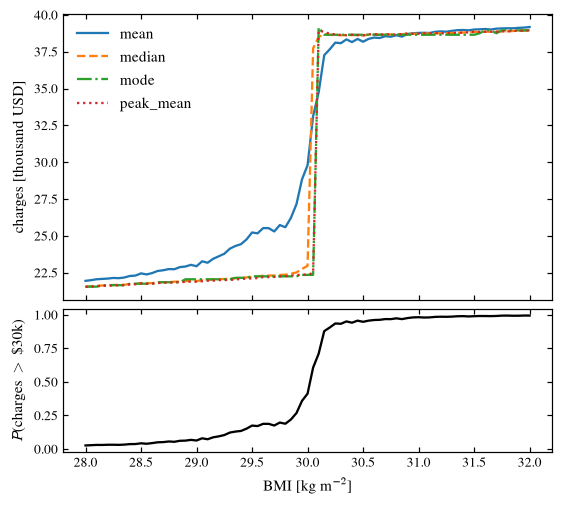

In [10]:
bmi = np.linspace(28, 32, 81)
person = pd.DataFrame(
    {
        "age": 40,
        "sex": 1,
        "bmi": bmi,
        "children": 1,
        "smoker": 1,
        "region": 1,
    }
)[X.columns]

methods = ["mean", "median", "mode", "peak_mean"]
sweep = {m: model.predict(person, method=m, y_grid=grid) for m in methods}
upper = 1 - model.predict_distribution(person).cdf([30_000])[:, 0]

fig, (ax, ax_mass) = plt.subplots(
    2,
    1,
    figsize=(5, 4.5),
    sharex=True,
    height_ratios=[2, 1],
    layout="constrained",
)
for m, ls in zip(methods, ["-", "--", "-.", ":"]):
    ax.plot(bmi, sweep[m] / 1e3, ls=ls, label=m)
ax.set_ylabel("charges [thousand USD]")
ax.legend()
ax_mass.plot(bmi, upper, color="k")
ax_mass.set_xlabel("BMI [kg m$^{-2}$]")
ax_mass.set_ylabel("$P$(charges $>$ \\$30k)")

shown = np.isin(bmi.round(2), [28.0, 29.0, 29.5, 29.9, 30.0, 30.1, 30.5, 32.0])
pd.DataFrame(sweep, index=bmi.round(2)).assign(**{"P(> $30k)": upper})[
    shown
].round(2)

The top panel shows the four point estimates against BMI, and the bottom
panel the probability that the charges exceed \$30,000. We see that the
median, the mode and the peak mean stay in the lower band, at about
\$22,000, up to a BMI of 30.0, and jump to between \$38,502 and \$39,150
at 30.1. The probability of the upper band, however, rises gradually below
the threshold, from 0.03 at a BMI of 28.0 to 0.17 at 29.5 and 0.41 at 30.0,
before climbing to 0.71 at 30.1 and 0.95 at 30.5. The mean follows this
probability rather than either band, and rises smoothly from \$21,944 at a
BMI of 28.0 to \$29,793 at 30.0, where neither band has much density.
Thus, for a BMI between about 29.5 and 30.1, the model is uncertain which
band this person belongs to, which only the full distribution shows.

## Four point estimates on the test set

We now compute the four point estimates for every test row. Calling
`predict` once per method runs the model four times, which is cheap for
335 rows. For larger tables, `model.point_estimates(pdfs, grid)` reduces
densities already in hand without running the model again.

In [11]:
points = pd.DataFrame(
    {m: model.predict(X_test, method=m, y_grid=grid) for m in methods},
    index=X_test.index,
)
spread = points.max(axis=1) - points.min(axis=1)
print(
    "Largest minus smallest of the four [USD]: "
    f"median {spread.median():,.0f}, 90th percentile "
    f"{spread.quantile(0.9):,.0f}, maximum {spread.max():,.0f}"
)
(points["mean"] - points["mode"]).groupby(X_test["smoker"]).describe().round()

Largest minus smallest of the four [USD]: median 788, 90th percentile 1,630, maximum 14,052


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
0,266.0,951.0,518.0,159.0,594.0,872.0,1205.0,4375.0
1,69.0,964.0,1848.0,-278.0,120.0,282.0,821.0,10227.0


In [12]:
largest = spread.nlargest(8).index
X_test.loc[largest, ["age", "bmi", "smoker"]].assign(
    spread=spread[largest].round()
)

,age,bmi,smoker,spread
652,24,29.830,1,14052.0
137,42,30.000,1,13190.0
676,25,29.700,1,5142.0
1113,61,29.920,1,4501.0
994,18,38.665,0,4375.0
649,19,29.070,1,3427.0
999,19,28.880,1,3276.0
562,59,29.830,1,3179.0


Across the test set, the largest and the smallest of the four estimates
differ by \$788 for the median row, by \$1,630 at the 90th percentile, and
by up to \$14,052. The second table splits the difference between the mean
and the mode by smoking status. For non-smokers, the mean exceeds the mode
in every row, by \$159 to \$4,375 (with a median of \$872). This might be
because of the sparse scatter above their band in the first figure, which
gives their densities a tail toward higher charges that pulls the mean up
but leaves the mode in place. For smokers, the typical difference is
smaller (a median of \$282), but it reaches \$10,227. The last table lists
the eight rows with the largest disagreement. Seven of them are smokers with
a BMI between 28.88 and 30.00, the three multimodal people among them, and
the eighth is a non-smoker.

## Sampling

`predict_distribution` returns the native answer of the model, on no grid,
and its `rvs` method draws values from each row. Here we draw 10,000 values
for the first multimodal person and compare their histogram with the density.

Fraction of draws above $30,000: 0.570
Probability above $30,000 from the CDF: 0.561


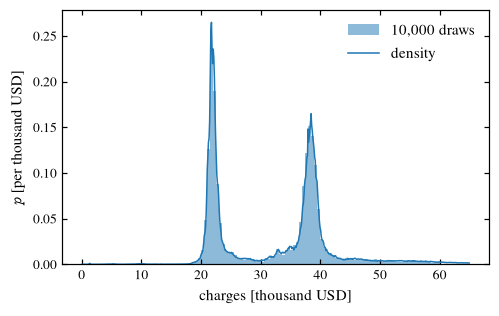

In [13]:
i = multimodal[0]
dist = model.predict_distribution(X_test.iloc[[i]])
draws = dist.rvs(10_000, random_state=SEED)[0]

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(
    draws / 1e3,
    bins=np.arange(0, 60.5, 0.5),
    density=True,
    color="C0",
    alpha=0.5,
    label="10,000 draws",
)
ax.plot(grid.centers / 1e3, pdfs[i] * 1e3, color="C0", lw=1, label="density")
ax.set_xlabel("charges [thousand USD]")
ax.set_ylabel("$p$ [per thousand USD]")
ax.legend()
print(f"Fraction of draws above $30,000: {np.mean(draws > 30_000):.3f}")
print(f"Probability above $30,000 from the CDF: {dist.sf([30_000])[0, 0]:.3f}")

We see that the histogram of the draws follows the density, both peaks
included. The fraction of draws above \$30,000 (0.570) is close to the
probability computed from the CDF (0.561), given that the standard error of a
fraction estimated from 10,000 draws is about 0.005. Draws like these can be
passed to any downstream calculation (e.g., the total charges of a group of
people) without reducing each person to a single number.

## Scoring distributions and point estimates

Point metrics score one number per row, and each favors a different point
estimate: the mean minimizes the expected squared error and the median the
expected absolute error. Proper scoring rules score the whole distribution
instead. The continuous ranked probability score (CRPS) is the integral of
the squared difference between the predicted CDF and the step function at the
true value. It is in the units of the target and reduces to the absolute
error for a single number, so it can be compared directly with the mean
absolute error. The negative log likelihood (NLL) is minus the logarithm of
the density at the true value. Lower is better for both.

In [14]:
residuals = points.sub(y_test, axis=0)
table = pd.DataFrame(
    {
        "MAE [USD]": residuals.abs().mean(),
        "RMSE [USD]": np.sqrt((residuals**2).mean()),
    }
)
print(table.round(0).to_string())
print(f"\nCRPS of the densities: {metrics.crps(y_test, grid, pdfs):,.0f} USD")
print(f"NLL of the densities:  {metrics.nll(y_test, grid, pdfs):.3f}")

           MAE [USD]  RMSE [USD]
mean          2443.0      5288.0
median        1788.0      5471.0
mode          1711.0      5374.0
peak_mean     1716.0      5379.0



CRPS of the densities: 1,649 USD
NLL of the densities:  6.711


No single point estimate is best on both point metrics. The mean has the
lowest RMSE (\$5,288) and the highest MAE (\$2,443), while the mode has the
lowest MAE (\$1,711). If the densities were exact, the median would have the
lowest expected absolute error, whereas here its MAE is slightly higher than
that of the mode (\$1,788 vs \$1,711). The CRPS of the densities, \$1,649, is
lower than the MAE of each of the four point estimates. The NLL (6.711) has
no point-estimate counterpart and depends on the units of the target (here,
densities per dollar), so it serves to compare models on the same target
rather than to be read on its own.

## Next steps

- [From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html):
  the native distributions, grids, point estimates and metrics.
- [One interface for every model](https://lazy-tfm.readthedocs.io/en/latest/guide/interface.html):
  the shared parameters and the inputs the models accept.